# Taller 2: operaciones de transformación del histograma

### Sebastián Palma

### David Tobón Molina

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

from skimage import exposure

## Segmentación por umbralización

#### 1.2 Cargue la imagen de trabajo objects.png  y visualícela

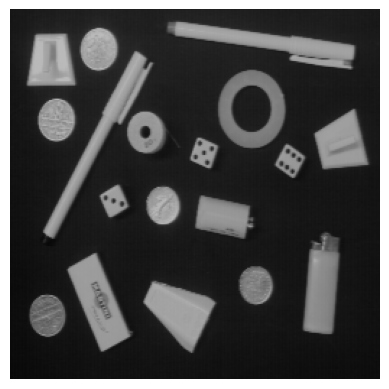

In [46]:
objects_img = cv2.imread('images/OBJECTS.png', cv2.IMREAD_GRAYSCALE)

plt.imshow(objects_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

#### 1.3 Visualice el histograma de la imagen de trabajo

In [47]:
def get_histogram(img):
    return cv2.calcHist([img],[0],None,[256],[0,256])

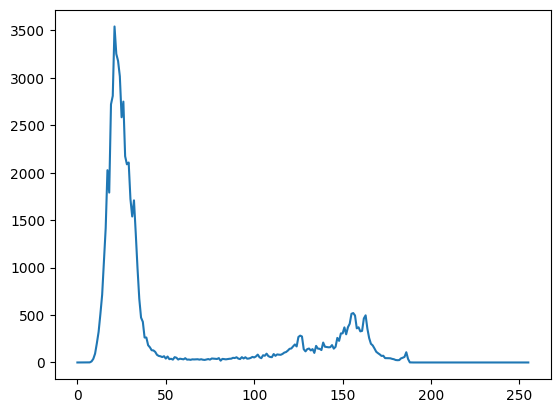

In [48]:
objects_hist = get_histogram(objects_img)

plt.plot(objects_hist)
plt.show()

#### 1.4 Aplique el algoritmo de umbralización global

In [49]:
max_value = 255
thresh_value, thresh_image = cv2.threshold(objects_img, 60, max_value, cv2.THRESH_BINARY)

#### 1.5 Aplique el algoritmo de umbralización de Otsu con un solo valor

In [50]:
otsu_value, otsu_image = cv2.threshold(objects_img, 0, max_value, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

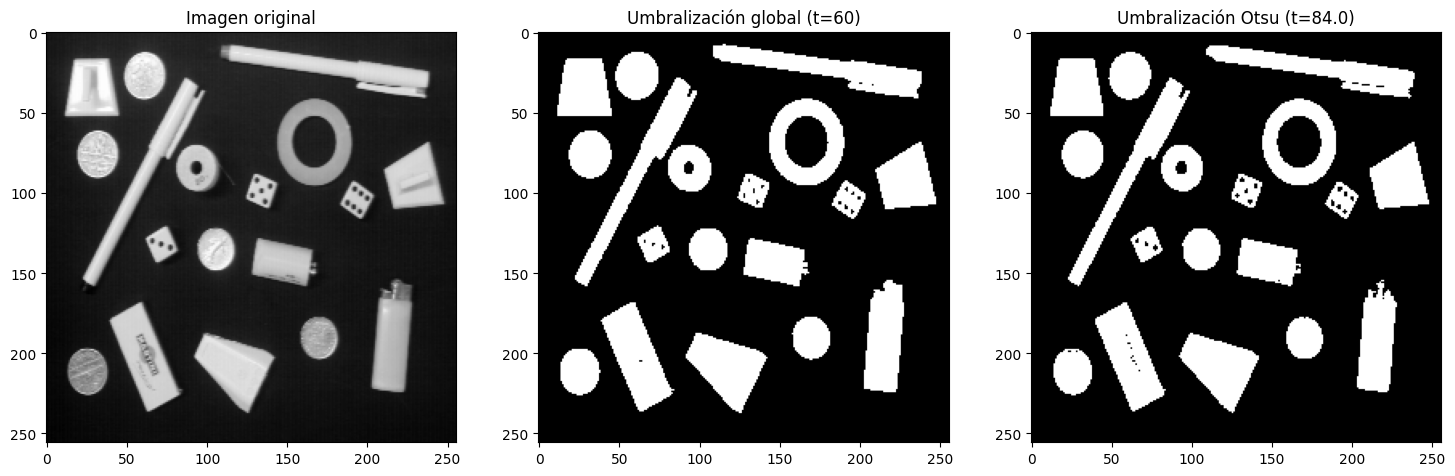

In [51]:
plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.title('Imagen original')
plt.imshow(objects_img, cmap='gray')

plt.subplot(1,3,2)
plt.title(f'Umbralización global (t={60})')
plt.imshow(thresh_image, cmap='gray')

plt.subplot(1,3,3)
plt.title(f'Umbralización Otsu (t={otsu_value})')
plt.imshow(otsu_image, cmap='gray')

plt.show()

#### 1.6 Ahora introduzca ruido gaussiano aditivo con varianza de 0.001 y luego con varianza de 0.05. Visualice el histograma de la imagen resultante. ¿Qué sucede? ¿Por qué sucede esto?

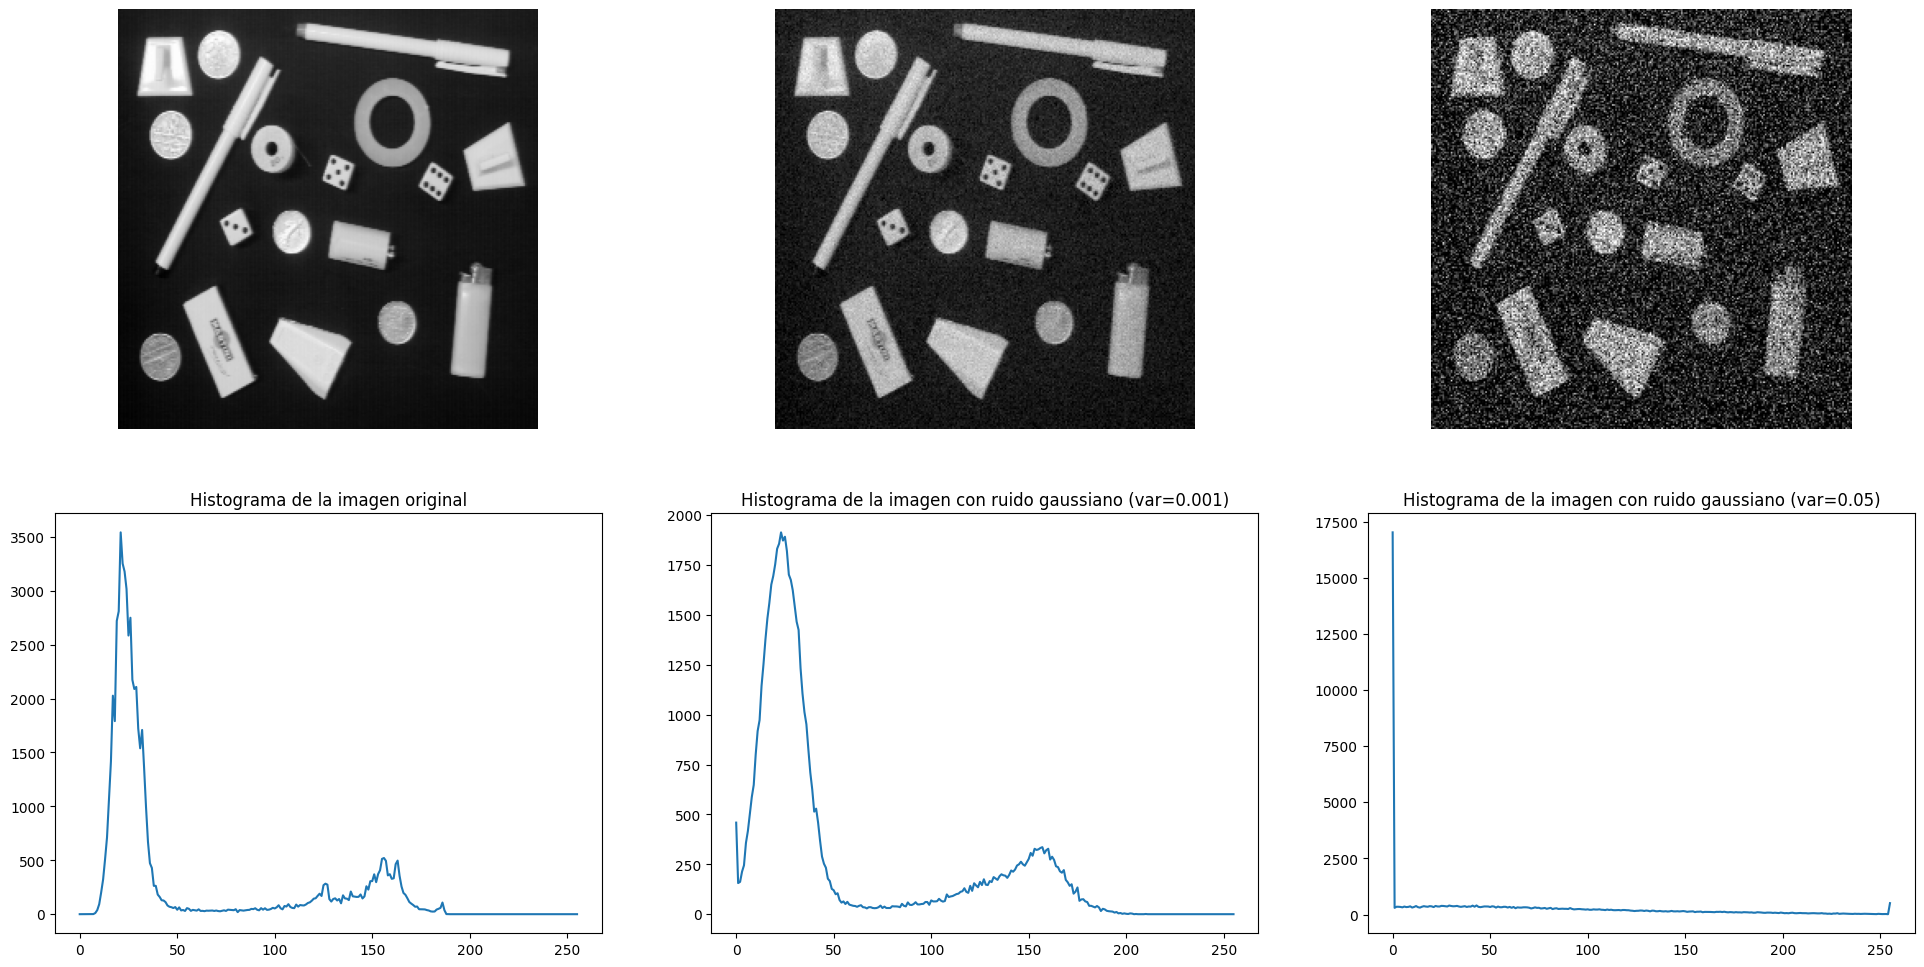

In [56]:
from skimage.util import random_noise

noised_image_001 = random_noise(objects_img, mode='gaussian', mean=0, var=0.001)
noised_image_05 = random_noise(objects_img, mode='gaussian', mean=0,  var=0.05)

noised_image_001 = (noised_image_001 * 255).astype(np.uint8)
noised_image_05 = (noised_image_05 * 255).astype(np.uint8)

noised_image_001_hist = get_histogram(noised_image_001)
noised_image_05_hist = get_histogram(noised_image_05)

plt.figure(figsize=(24, 12))

plt.subplot(2, 3, 1)
plt.imshow(objects_img, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(noised_image_001, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(noised_image_05, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.plot(objects_hist)
plt.title('Histograma de la imagen original')

plt.subplot(2, 3, 5)
plt.plot(noised_image_001_hist)
plt.title('Histograma de la imagen con ruido gaussiano (var=0.001)')

plt.subplot(2, 3, 6)
plt.plot(noised_image_05_hist)
plt.title('Histograma de la imagen con ruido gaussiano (var=0.05)')

plt.show()

Cuando la varianza del ruido es baja ($\sigma^2$ = 0.001), los picos del histograma que representan los valores de fondo (rango [10, 50]) y de los objetos (rango [100, 200]) incrementan su rango, pudiendose decir que se hacen más anchos: el pico que representa los valores de fondo se extiende poco, de [10,50] a [0, 50], pero se ve menos filudo porque los valores se distribuyen de manera más uniforme, ya el pico no es en 3500, sino en 1900. Adicionalmente, el valle que separa a ambos picos se vuelve menos profundo y más corto, implicando una mezcla entre los valores de intensidad de los objetos y el fondo. De todos modos, se observa que la estructura bimodal del histograma se mantiene.

Cuando la varianza del ruido es más alta ($\sigma^2$ = 0.001$), la estructura bimodal del histograma desaparece, mostrando qye no hay una distinción clara entre los objetos y el fondo. Además, hay un aplanamiento drástico del hitograma, donde solo presenta un pico en 0. Este pico también se explica dado que al sumar valores que pueden estar más alejados del valor original del píxel, los valores resultantes pueden ser negativos, por lo que recortan en 0 para cumplir con el rango de valores de la imagen.

Esto sucede porque al sumar ruido gaussiano, se le está sumando una variable aleatorio $N(0, \sigma^2)$ a las intensidades de los píxeles. Esto mueve los valores de los píxeles de manera aleatoria, y a mayor varianza, más ancha es la distribución de la variable aleatoria, por lo que el histograma original se aplana más. Esto se puede observar en la gráfica generada por el siguiente bloque de código (tener en cuenta que para esta suma los valores de intensidad de la imagen se convierten al rango [0, 1]).

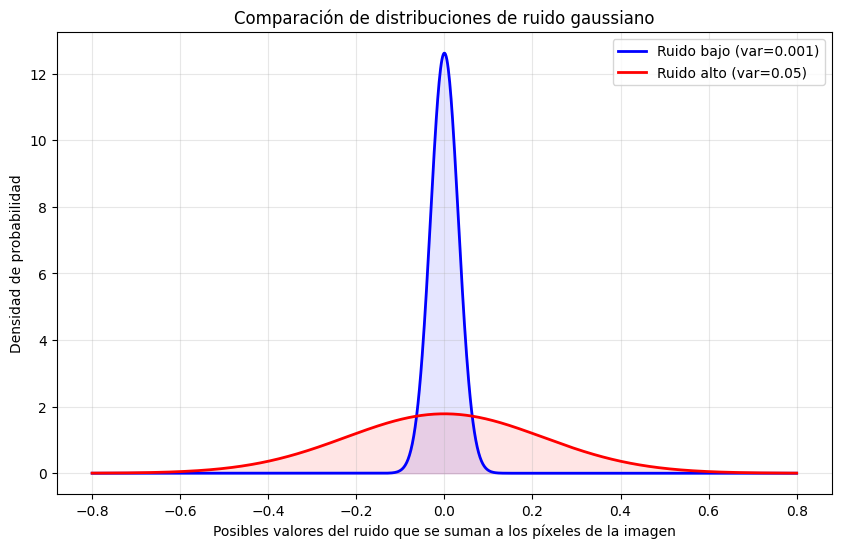

In [59]:
from scipy.stats import norm

x = np.linspace(-0.8, 0.8, 1000)

var1 = 0.001
std1 = np.sqrt(var1)
var2 = 0.05
std2 = np.sqrt(var2)

# genrar las distribuiones de probabilidad que representan el ruido
y1 = norm.pdf(x, 0, std1)
y2 = norm.pdf(x, 0, std2)

plt.figure(figsize=(10, 6))
plt.plot(x, y1, label=f'Ruido bajo (var={var1})', color='blue', linewidth=2)
plt.plot(x, y2, label=f'Ruido alto (var={var2})', color='red', linewidth=2)
plt.fill_between(x, y1, alpha=0.1, color='blue')
plt.fill_between(x, y2, alpha=0.1, color='red')

plt.title('Comparación de distribuciones de ruido gaussiano')
plt.xlabel('Posibles valores del ruido que se suman a los píxeles de la imagen')
plt.ylabel('Densidad de probabilidad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()